# EchoScope: Spotify Track Analysis & Recommendation System

## Song Recommendation

### Set up the libraries and the dataset

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # Plotting.
import seaborn as sns # Plotting.
from sklearn.metrics.pairwise import cosine_similarity # Cosine similarity between songs.
from sklearn.preprocessing import MinMaxScaler # Feature scaling.

# Start by loading the datasets and extracting the audio features for the cosine similarity computations.
tracks_df = pd.read_csv('dataset.csv') # To extract artist name and track name.
popularity_df = pd.read_csv('dataset_popularity.csv') # To extract and merge features.
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
                  'instrumentalness', 'liveness', 'valence', 'tempo']

# Take the missing columns from the original dataset for the merge.
cols_to_fix = ['track_name', 'artists', 'album_name', 'track_genre']

# Merge the datasets.
recommendations_df = pd.concat([tracks_df[cols_to_fix], popularity_df], axis=1)

# Drop eventual duplicates or null values.
recommendations_df = recommendations_df.sort_values('popularity', ascending=False) # Order by popularity to keep the most popular duplicate.
recommendations_df = recommendations_df.drop_duplicates(subset=['track_name', 'artists'], keep='first')
recommendations_df = recommendations_df.dropna(subset=['track_name', 'popularity_pred'])

#print(recommendations_df[['track_name', 'artists', 'cluster', 'popularity_pred']].head())

# Remember to scale the audio features to make sure the computations are consistent.
scaler = MinMaxScaler()
recommendations_df_scaled = recommendations_df.copy()
recommendations_df_scaled[audio_features] = scaler.fit_transform(recommendations_df[audio_features])

Write a function to check whether the input song is present in the dataset. <br>

In [11]:
def find_song(df, title, artist=None):
    # Case-insensitive search.
    result = df[df['track_name'].str.contains(title, case=False, na=False)]
    if artist:
        # Rapid check if you want to specify the artist's name as well.
        result = result[result['artists'].str.contains(artist, case=False, na=False)]
    if result.empty:
        print("Song not found.")
        return None
    # The first occurrence should be fine.
    return result.iloc[0]

# Example.
example_song = find_song(recommendations_df, "Starboy")
print(f"Chosen Song: {example_song['track_name']} - {example_song['artists']}.")

Chosen Song: Starboy - The Weeknd;Daft Punk.


### Recommendation algorithm

The recommendation algorithm takes a song title and, if present in the dataset, returns the $n$ most similar songs among its cluster. <br>
In particular, the comparisons will be made by computing the cosine similarity $\cos\theta = \frac{\mathbf{x}^T\mathbf{y}}{\lVert\mathbf{x}\rVert\lVert\mathbf{y}\rVert}$ between the songs $\mathbf{x}$ and $\mathbf{y}$. <br>
After computing the cosine similarity between the input song and each song in its cluster, the function computes the recommendation score as a weighted average between the songs similarity and the other song's predicted popularity score.

In [21]:
def song_recommendation(song_title, df, top_n=5):
    # Search the song in the dataset.
    song_ref = df[df['track_name'].str.contains(song_title, case=False, na=False)]
    if song_ref.empty:
        return "Song Not Found!"
    song_ref = song_ref.iloc[0]
    ref_cluster = song_ref['cluster'] # Find the song's cluster.
    # Just consider songs within the same cluster.
    candidate_pool = df[df['cluster'] == ref_cluster].copy()
    # Use the cosine similarity to evaluate how similar the input song is with the other songs in its cluster.
    similarities = cosine_similarity(
        [song_ref[audio_features]], 
        candidate_pool[audio_features]
    ).flatten()
    candidate_pool['similarity_score'] = similarities
    # Ranking Score considers the cosine similarity (70%) and the predicted popularity (30%).
    candidates_pop_norm = candidate_pool['popularity_pred'] / 100
    candidate_pool['final_rank'] = (candidate_pool['similarity_score'] * 0.7) + (candidates_pop_norm * 0.3)
    # Sort the songs by ranking score and take the top n results.
    recommendations = candidate_pool[candidate_pool['track_name'] != song_ref['track_name']] # Exclude the song itself.
    recommendations = recommendations.sort_values(by='final_rank', ascending=False).head(top_n)
    return recommendations[['track_name', 'artists', 'similarity_score', 'popularity', 'popularity_pred']]

# Try an example and check whether the recommendations are too mainstream or not.
top_recommendations = song_recommendation("Bubblegum Bitch", recommendations_df)
print(top_recommendations)
print(f"Mean Popularity of the Recommended Songs: {top_recommendations['popularity_pred'].mean():.2f}")

                                      track_name                     artists  \
44985                       Edge Of A Revolution                  Nickelback   
44519                              What It Takes                Adelitas Way   
86758                         The Sharpest Lives         My Chemical Romance   
50236                    Luzbelito y las Sirenas                     Asspera   
85063  Why Don't You Love Me (feat. Demi Lovato)  Hot Chelle Rae;Demi Lovato   

       similarity_score  popularity  popularity_pred  
44985          0.974245          57        44.008139  
44519          0.962968          59        46.623510  
86758          0.966615          66        45.402491  
50236          0.984268          27        40.513243  
85063          0.987280          60        39.306196  
Mean Popularity of the Recommended Songs: 43.17


For further investigation, it is possible to plot a radar chart explaining how the top recommendations are similar to the input song.

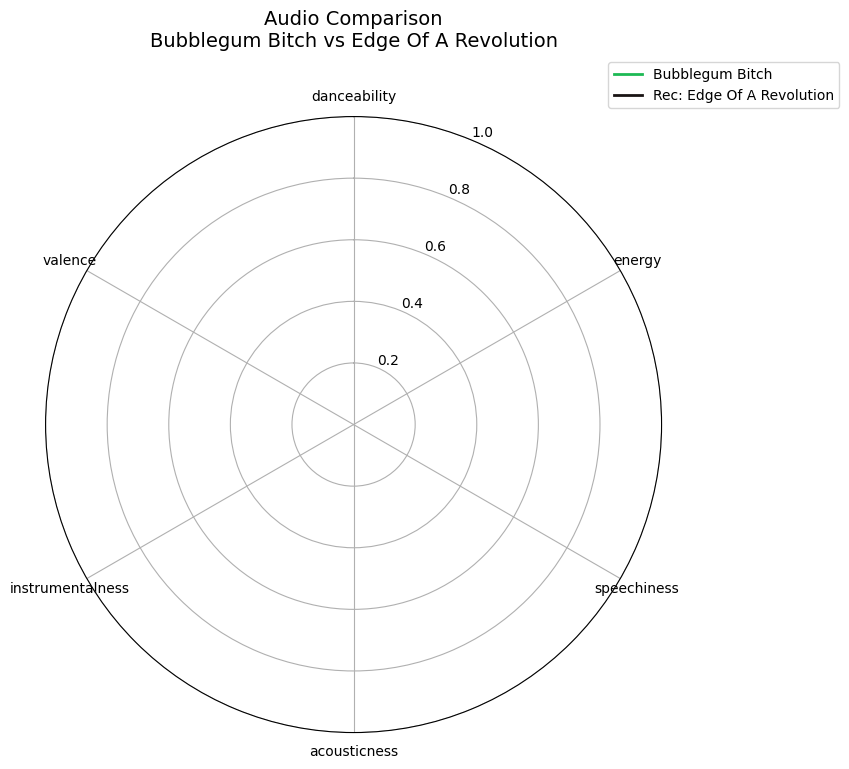

In [26]:
def plot_comparison(song_ref_name, rec_song_name, df):
    features = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'valence']
    # Take the data for the input song and the recommended song.
    try:
        res1 = df[df['track_name'] == song_ref_name].iloc[0][features].values.tolist() # Input song.
        res2 = df[df['track_name'] == rec_song_name].iloc[0][features].values.tolist() # Recommended song.
    except IndexError:
        print("Error: One of the songs was not found in the dataframe.")
        return
    res1 += res1[:1]
    res2 += res2[:1]
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]
    # Start creating the plot.
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    # Add the input song (green hue).
    ax.plot(angles, res1, color='#1DB954', linewidth=2, label=song_ref_name)
    ax.fill(angles, res1, color='#1DB954', alpha=0.3)
    # Add the recommended song (black/drak grey hue).
    ax.plot(angles, res2, color='#191414', linewidth=2, label=f"Rec: {rec_song_name}")
    ax.fill(angles, res2, color='#191414', alpha=0.2)
    # 4. Add details.
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), features)
    ax.set_ylim(0, 1) # Scale to [0, 1]-
    plt.title(f"Audio Comparison\n{song_ref_name} vs {rec_song_name}", y=1.1, fontsize=14)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Example.
plot_comparison("Bubblegum Bitch", top_recommendations.iloc[0]['track_name'], recommendations_df)

Furthermore, it is possible to use the song recommendation algorithm to create small playlists based on an input song.

In [29]:
def generate_playlist(song_title, df, num_songs=10):
    # Search for the input song and the artist.
    search_results = df[df['track_name'].str.contains(song_title, case=False, na=False)]
    if search_results.empty:
        return None, "Canzone non trovata."
    # Consider the most popular version of the song in case of unfiltered duplicates.
    song_ref = search_results.sort_values('popularity', ascending=False).iloc[0]
    source_info = {
        'title': song_ref['track_name'],
        'artist': song_ref['artists']
    }
    # Use the song recommendation algorithm to build the playlist.
    playlist_df = song_recommendation(song_ref['track_name'], recommendations_df, top_n=num_songs)
    return source_info, playlist_df

In [31]:
target_song = "Bubblegum Bitch"
source, playlist = generate_playlist(target_song, recommendations_df)

if source:
    print(f"🎵 EchoScope Playlist Generator")
    print(f"Based on: '{source['title']}' by {source['artist']}")
    print("-" * 45)
    # Plot the results.
    display_df = playlist[['track_name', 'artists']].reset_index(drop=True)
    display_df.index += 1 
    
    print(display_df)
else:
    print("Error: Song not found in the dataframe.")

🎵 EchoScope Playlist Generator
Based on: 'Bubblegum Bitch' by MARINA
---------------------------------------------
                                   track_name  \
1                        Edge Of A Revolution   
2                               What It Takes   
3                          The Sharpest Lives   
4                     Luzbelito y las Sirenas   
5   Why Don't You Love Me (feat. Demi Lovato)   
6                        Last Ride of the Day   
7                            Thnks fr th Mmrs   
8                          Highway Don't Care   
9                                 Superheroes   
10                      Nobody Praying For Me   

                                artists  
1                            Nickelback  
2                          Adelitas Way  
3                   My Chemical Romance  
4                               Asspera  
5            Hot Chelle Rae;Demi Lovato  
6                             Nightwish  
7                          Fall Out Boy  
8   Tim M

### Save the resulting dataframe

In [32]:
recommendations_df.to_csv('../EchoScope/echoscope_production_data.csv', index=False) # For API portability.